# Phase 4: Autonomous Recommendation Engine Architecture
## Task 1: The Math

Implementation of the $R_{score}$ formula using NumPy vectorization:

$$R_{score, i, \text{laptop}} = \left[ \alpha_L \left( \frac{\hat{P}_{t+14, i} - P_{t, i}}{P_{t, i}} \right) \right] + \left[ \beta_L (100 - V_i) \right] + \left[ \gamma_L \left( \frac{\mu_{14d, i} - P_{t, i}}{\mu_{14d, i}} \right) \right] - \left[ \delta_L (M_{age, i}) \right]$$


In [1]:
%pip install shap

  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/20/0e/6f581645b66efff6bf091953f474eb16e64da499cfac0c552dd77559f205/shap-0.51.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for numpy>=2 from https://files.pythonhosted.org/packages/2d/5b/e1deebf88ff431b01b7406ca3583ab2bbb90972bbe1c568732e49c844f7e/numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for tqdm>=4.27.0 from https://files.pythonhosted.org/packages/16/e1/3079a9ff9b8e11b846c6ac5c8b5bfb7ff225eee721825310c91b3b50304f/tqdm-4.67.3-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ---------------------------------------- 57.7/57.7 kB 1.0 MB/s eta 0:00:00
  Obtaining dependency information for slicer==0.0.8 from https://files.pythonhosted.org/packages/63/81/9ef641ff4e12cbcca30e54e72fb0951a2ba195d0cda0ba4100e532d929db/slicer-0.0.8-py3-none-any.whl.metadata
  Obtaining dependency informati


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import socketserver
import sys

# Patch: UnixStreamServer doesn't exist on Windows but pyspark (loaded by shap) expects it
if not hasattr(socketserver, 'UnixStreamServer'):
    socketserver.UnixStreamServer = socketserver.TCPServer

import numpy as np
import pandas as pd
import shap
import warnings
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')

def calculate_r_score(df, alpha_L=20.0, beta_L=1.0, gamma_L=1.0, delta_L=0.5):
    """Calculates the R_score using weighted economic factors."""
    p_t = df['current_price'].values
    p_t_14 = df['forecasted_price'].values
    v = df['volatility_score'].values
    mu_14d = df['price_14d_avg'].values
    m_age = df['months_since_release'].values
    
    # 1. Price Momentum: Rewards products with high forecasted growth
    momentum = (p_t_14 - p_t) / p_t
    term1 = alpha_L * momentum
    
    # 2. Stability Yield: Rewards low volatility (Stability = 100 - Volatility)
    term2 = beta_L * (100 - v)
    
    # 3. Discount Depth: Rewards buying below the 14-day historical average
    discount = (mu_14d - p_t) / mu_14d
    term3 = gamma_L * discount
    
    # 4. Obsolescence Penalty: Deducts points as the product gets older
    term4 = delta_L * m_age
    
    return term1 + term2 + term3 - term4

# ==========================================
# Load and Preprocess Real Data
# ==========================================
print("Loading data from Dataset_Pipeline_Processed.csv and ECom_Forecast_XAI_data.csv...")

# 1. Load Prices and Metadata from Processed Pipeline Data
processed_cols = ['scrape_timestamp', 'product_id', 'base_price_egp', 'price_14d_avg', 'D_months']
df_prices = pd.read_csv('Dataset_Pipeline_Processed.csv', usecols=processed_cols)

# 2. Load Scores and Forecasts from XAI Data
xai_cols = ['scrape_timestamp', 'product_id', 'predicted_stability_score', 'price_t_plus_14']
df_xai = pd.read_csv('ECom_Forecast_XAI_data.csv', usecols=xai_cols)

# 3. Merge Datasets
print("Merging datasets...")
df = pd.merge(df_prices, df_xai, on=['product_id', 'scrape_timestamp'])
df['scrape_timestamp'] = pd.to_datetime(df['scrape_timestamp'])

print("Processing features...")
df = df.sort_values(['product_id', 'scrape_timestamp'])

# Map columns for the R_score logic
df['current_price'] = df['base_price_egp']
df['forecasted_price'] = df['price_t_plus_14']
df['volatility_score'] = 100 - df['predicted_stability_score']
df['months_since_release'] = df['D_months']

# Filter for the LATEST available data point for each product
latest_data = df.sort_values('scrape_timestamp').groupby('product_id').tail(1).copy()

# Execute the scoring function
latest_data['r_score'] = calculate_r_score(latest_data)

# Rank products from highest score (Best) to lowest
ranked_df = latest_data.sort_values(by='r_score', ascending=False)

print("\nTop 5 Candidates from Real Data:")
display_cols = ['product_id', 'r_score', 'current_price', 'price_14d_avg', 'forecasted_price', 'volatility_score' , 'months_since_release']
print(ranked_df[display_cols].head())

# ==========================================
# Explainability Section (SHAP)
# ==========================================
try:
    print("\nGenerating SHAP explanations...")
    feature_cols = ['current_price', 'forecasted_price', 'volatility_score', 'price_14d_avg', 'months_since_release']
    X = ranked_df[feature_cols].dropna()
    y = ranked_df.loc[X.index, 'r_score']
    
    model = RandomForestRegressor(n_estimators=100).fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    print("[Success] SHAP explanations generated. You can now use shap.summary_plot(shap_values, X)")
except Exception as e:
    print(f"\n[Note] SHAP visualization skipped: {e}")


Loading data from Dataset_Pipeline_Processed.csv and ECom_Forecast_XAI_data.csv...
Merging datasets...
Processing features...

Top 5 Candidates from Real Data:
                                               product_id    r_score  \
103087  https://2b.com.eg/en/infinix-xpad-30e-4gb-ram-...  97.116232   
104224  https://2b.com.eg/en/infinix-xpad-gt-8gb-ram-2...  96.677010   
253550  https://dream2000.com/en/honor-600-lite-8gb-ra...  96.494837   
252792  https://dream2000.com/en/honor-600-lite-8gb-ra...  96.251934   
188741  https://2b.com.eg/en/vivo-v70-12gb-ram-256gb-g...  96.038791   

        current_price  price_14d_avg  forecasted_price  volatility_score  \
103087    9452.911133   10390.165334       9452.911133          2.514005   
104224   19994.142578   21938.405502      19994.142578          2.951646   
253550   22058.484375   24656.553265      22058.484375          2.641314   
252792   22082.150391   24537.270900      22082.150391          2.878904   
188741   32237.039062   351

In [8]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import sys
print(sys.executable)

B:\1234\attendance_system\.venv\Scripts\python.exe


In [11]:
import sys
!{sys.executable} -m pip install matplotlib

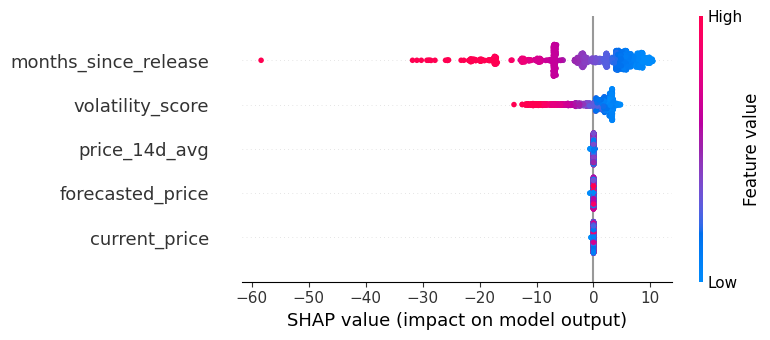

In [2]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X)

## Task 2: The Classifier
Scikit-Learn pipeline with an SVM RBF model acting as a 'State Detector' to classify laptops into categories like 'Deflating Arbitrage' or 'Hyper-Inflated'.


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

print("\nTraining State Detector on REAL Data logic...")

features_cols = [
    'current_price', 
    'forecasted_price', 
    'volatility_score', 
    'price_14d_avg', 
    'months_since_release'
]

X_train = latest_data[features_cols].fillna(0)

# إنشاء تسميات (Labels) منطقية ليتعلم منها الموديل
def label_logic(row):
    if row['r_score'] > 65 and row['volatility_score'] < 20:
        return 'Deflating Arbitrage'
    elif row['current_price'] > row['price_14d_avg'] * 1.2:
        return 'Hyper-Inflated'
    else:
        return 'Neutral'

y_train = latest_data.apply(label_logic, axis=1)

state_detector = Pipeline([
    ('scaler', StandardScaler()), 
    ('svm', SVC(
        kernel='rbf',           # استخدام الـ Radial Basis Function kernel
        probability=True,       # تفعيل خيار حساب الاحتمالات (Confidence)
        C=1.0,                  # معامل التنظيم (Regularization parameter)
        gamma='scale',          # معامل الـ Kernel
        random_state=42
    ))
])

state_detector.fit(X_train, y_train)

top_5_laptops = ranked_df.head(5).copy()
X_top_5 = top_5_laptops[features_cols]

top_5_laptops['state_classification'] = state_detector.predict(X_top_5)

probabilities = state_detector.predict_proba(X_top_5)
top_5_laptops['confidence'] = [f"{round(max(p) * 100, 2)}%" for p in probabilities]

print("\nClassification Results for Top 5 Candidates:")
display(top_5_laptops[['product_id', 'r_score' , 'volatility_score' , 'state_classification', 'confidence']])



Training State Detector on REAL Data logic...

Classification Results for Top 5 Candidates:


,product_id,r_score,volatility_score,state_classification,confidence
103087,https://2b.com.eg/en/infinix-xpad-30e-4gb-ram-...,97.116232,2.514005,Neutral,88.15%
104224,https://2b.com.eg/en/infinix-xpad-gt-8gb-ram-2...,96.677010,2.951646,Neutral,76.92%
253550,https://dream2000.com/en/honor-600-lite-8gb-ra...,96.494837,2.641314,Neutral,49.73%
252792,https://dream2000.com/en/honor-600-lite-8gb-ra...,96.251934,2.878904,Deflating Arbitrage,50.72%
188741,https://2b.com.eg/en/vivo-v70-12gb-ram-256gb-g...,96.038791,2.615093,Deflating Arbitrage,80.96%


## Task 3: Output
Python function that outputs a JSON payload for the top 5 candidates, including their SHAP values ($S_{shap, i}$).


In [4]:
import json

def generate_recommendation_payload(candidates_df, model, feature_names, background_data):
    """
    Outputs a JSON payload for the top candidates, including their SHAP values.
    """
    # 1. Filter for candidates classified as 'Deflating Arbitrage'
    valid_buys = candidates_df[candidates_df['state_classification'] == 'Deflating Arbitrage'].copy()
    
    if valid_buys.empty:
        print("Warning: No 'Deflating Arbitrage' candidates found in top 5. Using all top 5 for demonstration.")
        valid_buys = candidates_df.copy()
        
    # 2. Extract components from the pipeline
    svm_model = model.named_steps['svm']
    scaler = model.named_steps['scaler']
    
    # 3. Scale features for SHAP (Ensuring no NaNs, matching training logic)
    X_valid_scaled = scaler.transform(valid_buys[feature_names].fillna(0))
    X_background_sample = background_data[feature_names].sample(n=min(100, len(background_data)), random_state=42).fillna(0)
    X_background_scaled = scaler.transform(X_background_sample)
    
    # 4. Initialize SHAP KernelExplainer
    explainer = shap.KernelExplainer(svm_model.predict_proba, X_background_scaled)
    
    # 5. Calculate SHAP values
    shap_values = explainer.shap_values(X_valid_scaled, silent=True)
    
    # 6. Determine the index for the 'Deflating Arbitrage' class
    try:
        class_idx = list(svm_model.classes_).index('Deflating Arbitrage')
    except ValueError:
        class_idx = 0
        
    if isinstance(shap_values, list):
        target_shap_values = shap_values[class_idx]
    elif len(shap_values.shape) == 3:
        target_shap_values = shap_values[:, :, class_idx]
    else:
        target_shap_values = shap_values
        
    # 7. Construct the JSON Results
    results = []
    
    for idx, (row_idx, row) in enumerate(valid_buys.iterrows()):
        shap_drivers = {
            feat: round(float(target_shap_values[idx][i]), 4)
            for i, feat in enumerate(feature_names)
        }
        shap_drivers = dict(sorted(shap_drivers.items(), key=lambda item: abs(item[1]), reverse=True))
        
        candidate_payload = {
            "category": "laptop",
            "model": row['product_id'],
            "current_price": float(row['current_price']),
            "r_score": round(float(row['r_score']), 4),
            "classification": row['state_classification'],
            "confidence": row.get('confidence', 'N/A'),
            "shap_drivers": shap_drivers
        }
        results.append(candidate_payload)
        
    return json.dumps({"candidates": results}, indent=4)

json_payload = generate_recommendation_payload(
    candidates_df=top_5_laptops, 
    model=state_detector, 
    feature_names=features_cols, 
    background_data=latest_data
)

print("\nFinal JSON Payload with SHAP values:")
print(json_payload)



Final JSON Payload with SHAP values:
{
    "candidates": [
        {
            "category": "laptop",
            "model": "https://dream2000.com/en/honor-600-lite-8gb-ram-256gb-sprout-green-free-earbuds-x7e-active-cover-metal.html",
            "current_price": 22082.150390625,
            "r_score": 96.2519,
            "classification": "Deflating Arbitrage",
            "confidence": "50.72%",
            "shap_drivers": {
                "months_since_release": -0.345,
                "volatility_score": -0.0355,
                "current_price": -0.0068,
                "forecasted_price": -0.0068,
                "price_14d_avg": 0.0046
            }
        },
        {
            "category": "laptop",
            "model": "https://2b.com.eg/en/vivo-v70-12gb-ram-256gb-grey.html",
            "current_price": 32237.0390625,
            "r_score": 96.0388,
            "classification": "Deflating Arbitrage",
            "confidence": "80.96%",
            "shap_drivers": {
    